In [1]:
import pandas as pd
import numpy as np

In [2]:
# 1. Load the Twitter dataset
df = pd.read_csv(r'C:\Users\ajasl\OneDrive\Documents\Project\OIBSIP\Task_4\Twitter_Data.csv\Twitter_Data.csv')

In [3]:
# 2. Inspect the dataset structure
print("Dataset Shape:", df.shape)

Dataset Shape: (162980, 2)


In [4]:
# 3. Check for any missing values before we start text processing
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
clean_text    4
category      7
dtype: int64


In [5]:
# 4. Look at the first few rows to see the tweets and their sentiment categories
pd.set_option('display.max_colwidth', None) # This lets us read the full tweet
display(df.head())

,clean_text,category
0,when modi promised “minimum government maximum governance” expected him begin the difficult job reforming the state why does take years get justice state should and not business and should exit psus and temples,-1.0
1,talk all the nonsense and continue all the drama will vote for modi,0.0
2,what did just say vote for modi welcome bjp told you rahul the main campaigner for modi think modi should just relax,1.0
3,asking his supporters prefix chowkidar their names modi did great service now there confusion what read what not now crustal clear what will crass filthy nonsensical see how most abuses are coming from chowkidars,1.0
4,answer who among these the most powerful world leader today trump putin modi may,1.0


In [6]:
# 1. Drop the missing values (since there are so few, deleting them is safest)
df = df.dropna()

In [7]:
# 2. Verify the missing values are completely gone
print("--- Missing Values AFTER Cleaning ---")
print(df.isnull().sum())

--- Missing Values AFTER Cleaning ---
clean_text    0
category      0
dtype: int64


In [8]:
# 3. Let's see the breakdown of Positive (1), Neutral (0), and Negative (-1) tweets
print("\n--- Sentiment Breakdown ---")
print(df['category'].value_counts())


--- Sentiment Breakdown ---
category
 1.0    72249
 0.0    55211
-1.0    35509
Name: count, dtype: int64


In [9]:
# 4. Import the tool we need to turn text into numbers!
from sklearn.feature_extraction.text import CountVectorizer
print("\n✅ Scikit-Learn tool imported successfully!")


✅ Scikit-Learn tool imported successfully!


In [10]:
from sklearn.model_selection import train_test_split

# 1. Separate our text (X) and our target sentiments (y)
X = df['clean_text']
y = df['category']

In [11]:
# 2. Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data size: {X_train.shape[0]} tweets")
print(f"Testing data size: {X_test.shape[0]} tweets")

Training data size: 130375 tweets
Testing data size: 32594 tweets


In [12]:
# 3. Initialize the Vectorizer 
# (We limit it to the top 5,000 most common words so our computers don't crash!)
vectorizer = CountVectorizer(max_features=5000)

In [13]:
# 4. Transform the English text into a mathematical matrix!
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("\n✅ Text successfully converted to numbers!")
print("Matrix shape:", X_train_vec.shape)


✅ Text successfully converted to numbers!
Matrix shape: (130375, 5000)


In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize our Machine Learning model
model = MultinomialNB()

In [15]:
# 2. Train the model using our mathematical matrix!
print("Training the model... (this might take a few seconds)")
model.fit(X_train_vec, y_train)
print("✅ Model trained successfully!")

Training the model... (this might take a few seconds)
✅ Model trained successfully!


In [16]:
# 3. Quiz the model on the 20% Testing data it has never seen before
predictions = model.predict(X_test_vec)

In [17]:
# 4. Grade the model! How accurate was it?
accuracy = accuracy_score(y_test, predictions)
print(f"\n🏆 Model Accuracy: {accuracy * 100:.2f}%")


🏆 Model Accuracy: 80.84%


In [18]:
# 5. Print a detailed report card
print("\n--- Detailed Report Card ---")
print(classification_report(y_test, predictions))


--- Detailed Report Card ---
              precision    recall  f1-score   support

        -1.0       0.71      0.75      0.73      7152
         0.0       0.89      0.78      0.83     11067
         1.0       0.81      0.86      0.83     14375

    accuracy                           0.81     32594
   macro avg       0.80      0.80      0.80     32594
weighted avg       0.81      0.81      0.81     32594



In [19]:
# 1. Define a function to test any custom sentence
def predict_sentiment(custom_tweet):
    # Convert the text into the exact same numerical matrix format as our training data
    vec_text = vectorizer.transform([custom_tweet])
    
    # Predict using the trained Naive Bayes model
    prediction = model.predict(vec_text)[0]
    
    # Map the numerical prediction back to a readable text label
    sentiment_map = {-1: "Negative 🔴", 0: "Neutral 🟡", 1: "Positive 🟢"}
    return sentiment_map[prediction]

In [20]:
# 2. Test some example phrases
print("Test 1:", predict_sentiment("This project is absolutely amazing and I love it!"))
print("Test 2:", predict_sentiment("It is raining outside today."))
print("Test 3:", predict_sentiment("I am so frustrated because the code keeps breaking and it is terrible."))

Test 1: Positive 🟢
Test 2: Neutral 🟡
Test 3: Negative 🔴


In [29]:
# 3. Try your own! Change the text inside the quotes below:
my_sentence = "Type whatever you want here to see if the model can guess the sentiment correctly!"
print("\nYour Custom Test:", predict_sentiment(my_sentence))


Your Custom Test: Neutral 🟡


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

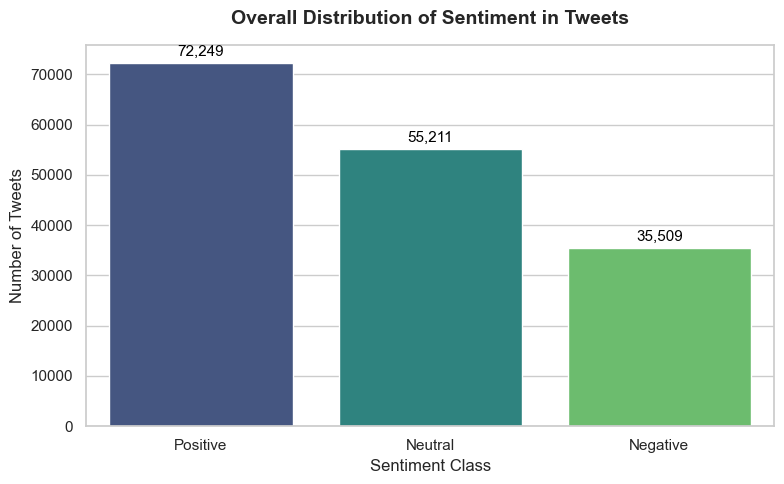

In [27]:
# 1. Set the background style for the chart
sns.set_theme(style="whitegrid")

# 2. Create the figure size
plt.figure(figsize=(8, 5))

# 3. Map the numerical categories to readable text labels for the plot
sentiment_counts = df['category'].value_counts().rename({-1: 'Negative', 0: 'Neutral', 1: 'Positive'})

# 4. Create a bar plot using Seaborn
ax = sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, hue=sentiment_counts.index, palette="viridis", legend=False)

# 5. Add titles and labels
plt.title('Overall Distribution of Sentiment in Tweets', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sentiment Class', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)

# 6. Add the exact numbers on top of each bar for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                fontsize=11, color='black', 
                xytext=(0, 5), 
                textcoords='offset points')

# 7. Show the beautiful plot!
plt.tight_layout()
plt.show()